# Data Engineering - E-commerce Product Analysis

This notebook explores the scraped laptop product data from the PostgreSQL database.

**Database Connection:**
- Host: localhost (or 'db' in Docker)
- Database: de_test_danone
- User: postgres
- Schema: raw (for raw data), processed (for cleaned data)

## 1. Setup and Database Connection

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

# Konfigurasi Visualisasi Profesional
plt.style.use('fivethirtyeight') # Style yang bersih dan profesional
sns.set_context("talk") # Ukuran font yang pas untuk presentasi
colors = sns.color_palette("viridis", 10)

# Database connection (Gunakan parameter Anda)
DB_CONFIG = {
    'host': 'localhost',
    'user': 'postgres',
    'pass': 'One123123ls',
    'db': 'de_test_danone',
    'port': '5432'
}

engine = create_engine(f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['pass']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['db']}")

# Load Data Terproses (Data yang sudah melewati ETL dm_product_specs)
query = "SELECT * FROM transformed.dm_product_specs"
df = pd.read_sql(query, engine)

# Konversi harga ke numerik untuk plotting
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['screen_size'] = pd.to_numeric(df['screen_size'], errors='coerce')

print(f"✓ Berhasil memuat {len(df)} data laptop untuk analisis.")

✓ Berhasil memuat 117 data laptop untuk analisis.


### 2. Segmentasi Harga & Brand (Market Positioning)
Analisis ini menunjukkan posisi setiap brand di pasar (Budget vs Premium).


/var/folders/rx/yxjwpxwx4pq0wphj00lvkp7r0000gn/T/ipykernel_28441/2778484359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_price', y='brand', data=brand_stats, palette='magma')


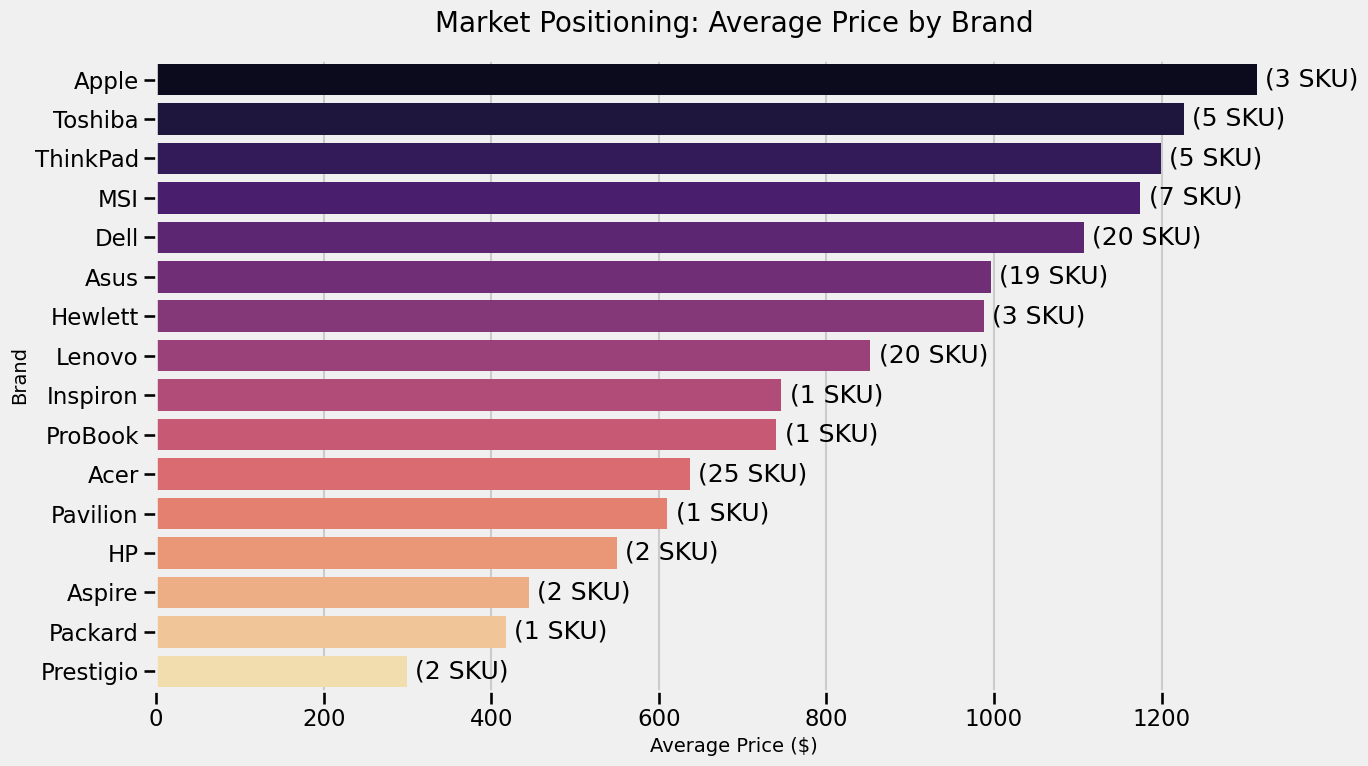

In [2]:
plt.figure(figsize=(14, 8))

# Agregasi data brand
brand_stats = df.groupby('brand').agg({
    'price': ['mean', 'count'],
    'id': 'count'
}).reset_index()
brand_stats.columns = ['brand', 'avg_price', 'product_count', 'total']
brand_stats = brand_stats.sort_values('avg_price', ascending=False)

# Bar Plot: Rata-rata Harga per Brand
sns.barplot(x='avg_price', y='brand', data=brand_stats, palette='magma')
plt.title('Market Positioning: Average Price by Brand', fontsize=20, pad=20)
plt.xlabel('Average Price ($)', fontsize=14)
plt.ylabel('Brand', fontsize=14)

# Tambahkan anotasi jumlah produk
for i, v in enumerate(brand_stats['product_count']):
    plt.text(brand_stats['avg_price'].iloc[i] + 10, i, f"({v} SKU)", color='black', va='center')

plt.tight_layout()
plt.show()

### 3. Korelasi Spesifikasi terhadap Harga
Menggunakan Heatmap untuk melihat variabel apa yang paling berpengaruh terhadap harga.

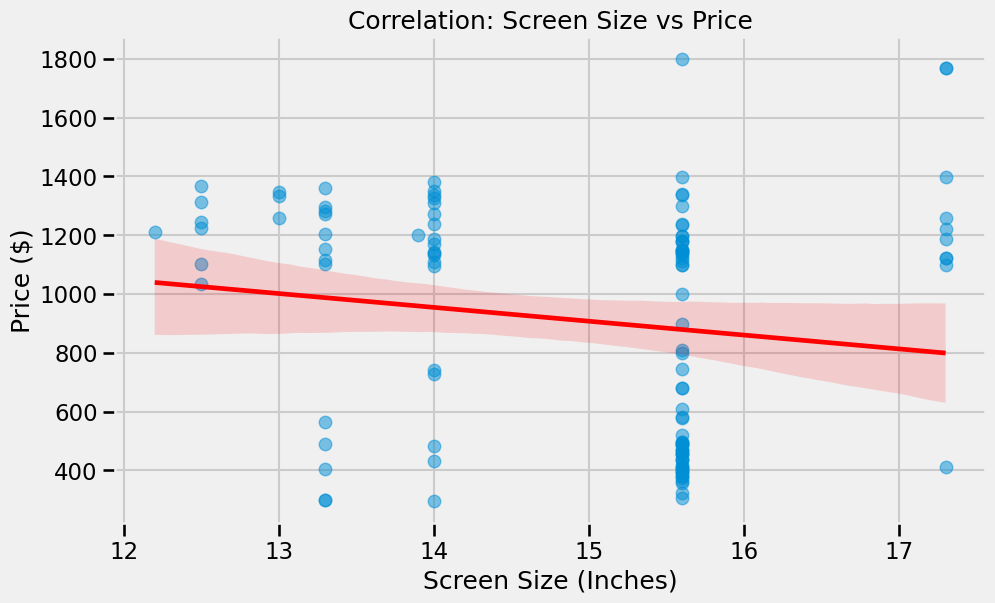

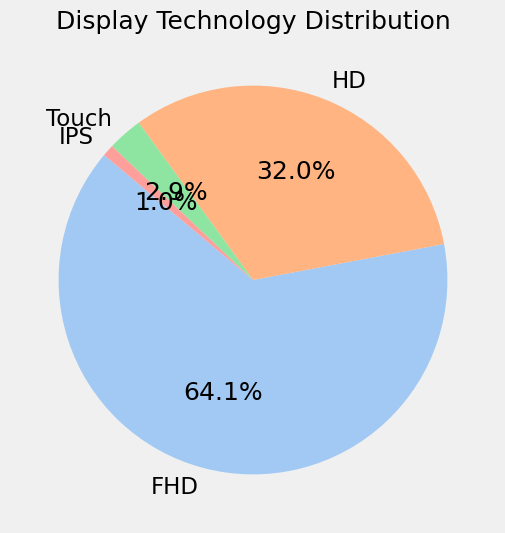

In [3]:
# Analisis Korelasi (Screen Size vs Price)
plt.figure(figsize=(10, 6))
sns.regplot(x='screen_size', y='price', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Correlation: Screen Size vs Price', fontsize=18)
plt.xlabel('Screen Size (Inches)')
plt.ylabel('Price ($)')
plt.show()

# Distribusi Tipe Display
plt.figure(figsize=(10, 6))
df['display_type'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Display Technology Distribution', fontsize=18)
plt.ylabel('')
plt.show()

### 4. Analisis Penyimpanan (HDD/SSD Capacity)
Kita ingin melihat distribusi kapasitas storage yang paling umum di pasar.

<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/var/folders/rx/yxjwpxwx4pq0wphj00lvkp7r0000gn/T/ipykernel_28441/4184609137.py:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['storage_gb'] = df['storage'].str.extract('(\d+)').astype(float)


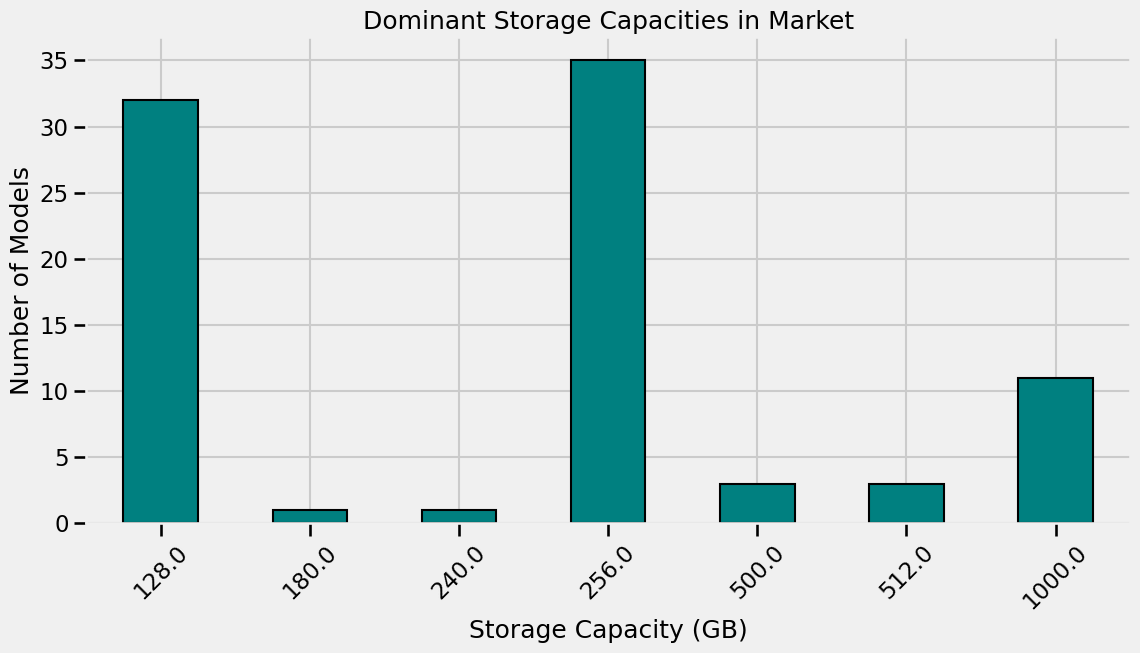

In [4]:
plt.figure(figsize=(12, 6))

# Membersihkan data hdd untuk plotting sederhana
df['storage_gb'] = df['storage'].str.extract('(\d+)').astype(float)
# Koreksi TB ke GB (misal 1TB = 1000GB)
df.loc[df['storage'].str.contains('TB', na=False), 'storage_gb'] *= 1000

storage_dist = df['storage_gb'].value_counts().sort_index()
storage_dist.plot(kind='bar', color='teal', edgecolor='black')

plt.title('Dominant Storage Capacities in Market', fontsize=18)
plt.xlabel('Storage Capacity (GB)')
plt.ylabel('Number of Models')
plt.xticks(rotation=45)
plt.show()

### 5. Price Heatmap: OS vs Brand
Insight ini sangat berguna untuk melihat preferensi sistem operasi pada rentang harga tertentu.

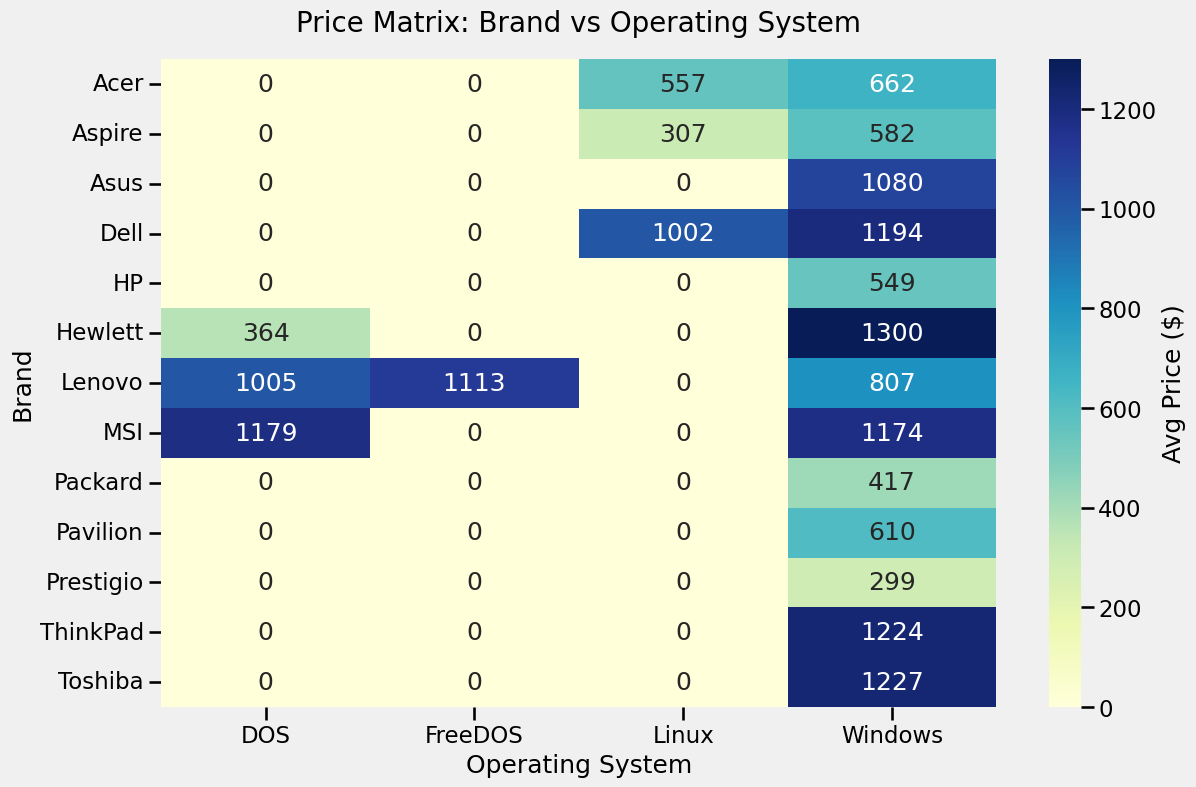

In [5]:
# Pivot data untuk Heatmap
pivot_df = df.pivot_table(index='brand', columns='os', values='price', aggfunc='mean').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Avg Price ($)'})
plt.title('Price Matrix: Brand vs Operating System', fontsize=20, pad=20)
plt.xlabel('Operating System')
plt.ylabel('Brand')
plt.show()

### 6. Analisis Value for Money (Price vs Rating)
Insight profesional untuk melihat apakah produk mahal selalu mendapatkan rating tinggi.

/var/folders/rx/yxjwpxwx4pq0wphj00lvkp7r0000gn/T/ipykernel_28441/4169470346.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='price', data=df_rating, palette='Set3')


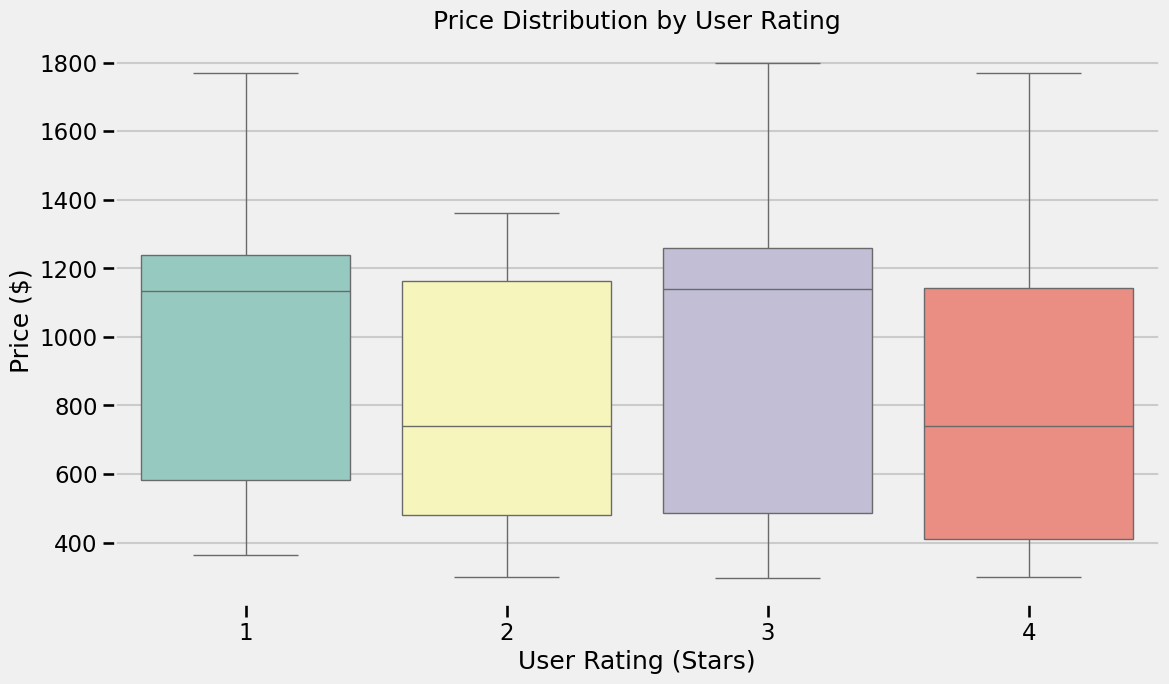

In [6]:
plt.figure(figsize=(12, 7))

# Kita asumsikan rating diambil dari data mentah (df_products original)
# Disini kita join kembali jika perlu, atau gunakan data dari raw.products
query_rating = "SELECT product_name, price, rating FROM raw.products"
df_rating = pd.read_sql(query_rating, engine)

sns.boxplot(x='rating', y='price', data=df_rating, palette='Set3')
plt.title('Price Distribution by User Rating', fontsize=18)
plt.xlabel('User Rating (Stars)')
plt.ylabel('Price ($)')
plt.show()